Enter number of reviews: 4
Enter review 1: The product quality is excellent and delivery was fast.
Enter review 2: Very bad service and poor packaging
Enter review 3: Excellent quality and amazing customer support.
Enter review 4: Packaging was damaged but delivery was quick.

Topics:

Topic 1:
packaging
delivery
service
poor
bad

Topic 2:
quality
excellent
delivery
support
customer

t-SNE Coordinates:
Review 1: [-198.30098  143.7894 ]
Review 2: [ -19.520504 -182.5235  ]
Review 3: [-104.58582  253.78232]
Review 4: [-148.16846 -116.6602 ]


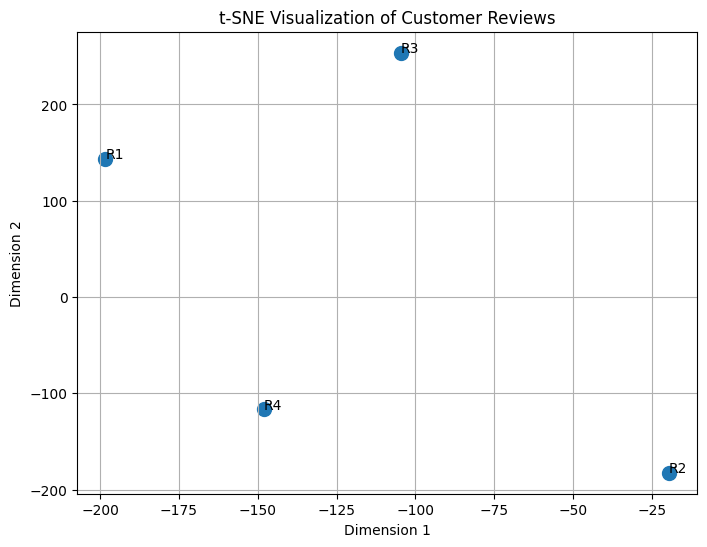

In [1]:
# Install required libraries (only if needed)
!pip -q install nltk

import nltk
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE

# Input customer reviews
reviews = []

n = int(input("Enter number of reviews: "))

for i in range(n):
    review = input(f"Enter review {i+1}: ")
    reviews.append(review)

# Convert text into document-term matrix
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(reviews)

# Apply LDA Topic Modeling
lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(X)

# Get feature names
words = vectorizer.get_feature_names_out()

# Display Topics
print("\nTopics:")
for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}:")
    top_words = topic.argsort()[-5:][::-1]   # Top 5 words
    for j in top_words:
        print(words[j])

# Convert sparse matrix to dense matrix
X_dense = X.toarray()

# t-SNE Visualization
# Perplexity must be less than the number of samples
perplexity = min(2, len(reviews) - 1)

if len(reviews) > 1:
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity
    )

    X_tsne = tsne.fit_transform(X_dense)

    print("\nt-SNE Coordinates:")
    for i, point in enumerate(X_tsne):
        print(f"Review {i+1}: {point}")

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1], s=100)

    for i in range(len(reviews)):
        plt.text(
            X_tsne[i,0],
            X_tsne[i,1],
            f"R{i+1}",
            fontsize=10
        )

    plt.title("t-SNE Visualization of Customer Reviews")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.show()

else:
    print("\nAt least 2 reviews are required for t-SNE visualization.")